# 🔍 LLM Explorer — The 4GB VRAM Decision Guide
## How to Pick the Right AI Model for Your Machine

**What this notebook does:**
-  Fetches real model data from the HuggingFace API
-  Calculates true VRAM requirements across quantization levels
-  Filters models that actually run within your VRAM budget
-  Guides you to pick the right model for your use case

> 🎯 **Who this notebook is for:** Beginners and learners who want a guided, transparent decision process — not just a list.
> HuggingFace's own filter has far more models, but it won't calculate VRAM per quantization level, rank models by efficiency, or walk you through a decision framework. This notebook does all three.
> Think of it as a **teaching tool + decision assistant**, not a complete model directory.

---
> 📌 **Data source**: HuggingFace Official API · Inspired by [llm-explorer.com/list/?4GB](https://llm-explorer.com/list/?4GB)

**Attribution**
Notebook developed by SzuLun Huang <szuh@berkeley.edu>  
Under the guidance of Eric Van Dusen <ericvd@berkeley.edu>  
UC Berkeley, Data Science

---
## 🖥️ Step 0 — Check Your Own VRAM First

Before picking a model, you need to know how much GPU memory your machine has.

---

### 🪟 Windows
1. Press **`Ctrl + Shift + Esc`** to open Task Manager
2. Click the **"Performance"** tab
3. Click **"GPU"** on the left
4. Look for **"Dedicated GPU Memory"** — that's your VRAM

---

### 🍎 Mac (Apple Silicon — M1 / M2 / M3 / M4)
1. Click the **Apple menu** (top-left corner) → "About This Mac"
2. Look at **"Memory"** — this is your Unified Memory (shared between CPU and GPU)
3. **Rule of thumb**: You can safely give ~**half** to an LLM

> Example: 16 GB Mac → ~6–8 GB available for a model (leaving room for macOS + browser + other apps)

---

### 🐧 Linux
Open a terminal and run:
```bash
lspci | grep -i vga
nvidia-smi
```
Look for the **"Memory-Usage"** row — the total is your VRAM.

---

### ⚠️ The "Just Because You Have It Doesn't Mean You Should Use All of It" Rule
**A smarter approach:**

| Your Total Memory | Recommended Model Budget | Leave for System |
|-------------------|--------------------------|------------------|
| 4 GB              | ≤ 3 GB                   | ~1 GB            |
| 8 GB              | ≤ 5 GB                   | ~3 GB            |
| 16 GB             | ≤ 8 GB                   | ~8 GB            |
| 32 GB             | ≤ 20 GB                  | ~12 GB           |



---
##  Background — Why Does VRAM Matter?

VRAM (Video RAM) is the memory on your GPU. When you run an LLM, all the model weights need to fit inside it.

| Quantization | Bytes per Parameter | Quality | Notes |
|-------------|---------------------|---------|-------|
| FP32        | 4 bytes             | Best    | Rarely used for inference |
| FP16        | 2 bytes             | Excellent | Most common training format |
| Q8          | 1 byte              | Near-lossless | Great balance |
| Q4          | 0.5 bytes           | Good    | ~5–10% quality loss, runs anywhere |

**Formula**: `VRAM (GB) ≈ Parameters (B) × bytes_per_param × 1.10 (overhead)`

**4GB is the VRAM of entry-level GPUs** (RTX 3050, older MacBooks) — the lowest common denominator for running local LLMs.

In [1]:
# @title ⚙️ Step 1 — Install & Import Packages { display-mode: "form" }
!pip install huggingface-hub pandas numpy matplotlib seaborn ipywidgets pyyaml -q

import warnings
warnings.filterwarnings('ignore')

from huggingface_hub import list_models, model_info
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, HTML

plt.rcParams['figure.figsize'] = (14, 7)
sns.set_style('whitegrid')

print('✅ All packages ready!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.8 MB/s eta 0:00:00
✅ All packages ready!


In [2]:
# @title 📥 Step 2 — Fetch Real Model Data from HuggingFace (About 90-120s) { display-mode: "form" }
print('Connecting to HuggingFace API...\n')

search_terms = [
    'llama', 'mistral', 'qwen', 'phi', 'gemma',
    'deepseek', 'tinyllama', 'falcon', 'stablelm',
    'smollm', 'openchat', 'openhermes'
]

all_models = []
for term in search_terms:
    try:
        print(f'  Searching "{term}"...')
        models = list_models(search=term, limit=100, sort='downloads', direction=-1)
        all_models.extend(models)
    except Exception as e:
        print(f'  ⚠️ Skipped "{term}": {e}')

# Deduplicate by model ID
unique_models = {}
for model in all_models:
    if model.id not in unique_models:
        unique_models[model.id] = model

print(f'\nFound {len(unique_models)} unique models')
print('Reading model cards for real parameter counts...\n')

# License keywords that allow commercial use
COMMERCIAL_LICENSES = ['apache', 'mit', 'llama', 'cc-by', 'openrail', 'bigscience']

data = []
count = 0

for model_id, model in unique_models.items():
    try:
        info = model_info(model_id)
        params_b       = None
        context_length = None
        license_str    = ''

        # Try reading metadata from model card YAML
        if hasattr(info, 'card_data') and info.card_data:
            if hasattr(info.card_data, 'get'):
                params_b       = info.card_data.get('parameters', None)
                context_length = info.card_data.get('max_position_embeddings', None)
                license_str    = info.card_data.get('license', '') or ''

        # Fallback: parse parameter count from model name
        if not params_b:
            model_lower = model_id.lower()
            param_map = {
                '0.5b': 0.5, '1b': 1.0, '1.1b': 1.1, '1.3b': 1.3,
                '1.5b': 1.5, '2b': 2.0, '3b': 3.0, '3.8b': 3.8,
                '4b': 4.0, '6b': 6.0, '7b': 7.0, '8b': 8.0,
                '13b': 13.0, '14b': 14.0, '70b': 70.0, '72b': 72.0
            }
            for key in sorted(param_map.keys(), key=len, reverse=True):
                if key in model_lower:
                    params_b = str(param_map[key]) + 'B'
                    break

        if params_b:
            model_lower = model_id.lower()
            data.append({
                'Model Name':     model_id,
                'Parameters':     params_b,
                'Downloads':      getattr(model, 'downloads', 0) or 0,
                'Likes':          getattr(model, 'likes', 0) or 0,
                'Created_At':     getattr(model, 'created_at', None),
                # Context length — 0 if not specified in model card
                'Context_Length': context_length or 0,
                # True if license allows commercial use
                'Commercial_OK':  any(lic in license_str.lower() for lic in COMMERCIAL_LICENSES),
                'Is_Code':        any(k in model_lower for k in ['code', 'coder', 'coding', 'deepseek-coder']),
                'Is_Chat':        any(k in model_lower for k in ['chat', 'instruct', '-it', 'assistant']),
                'Is_Math': any(k in model_lower for k in ['math', 'reasoning', 'deepseek-r', 'qwen-math']),
            })
            count += 1
            if count % 20 == 0:
                print(f'  Processed {count} models...')
    except Exception as e:
        pass  # skip models with missing/malformed metadata

df = pd.DataFrame(data)
df = df.sort_values('Downloads', ascending=False).reset_index(drop=True)
print(f'\n✅ Successfully loaded {len(df)} models with real parameters!')
print(f'   Context length available: {(df["Context_Length"] > 0).sum()} models')
print(f'   Commercial use OK:        {df["Commercial_OK"].sum()} models')

Connecting to HuggingFace API...

  Searching "llama"...
  Searching "mistral"...
  Searching "qwen"...
  Searching "phi"...
  Searching "gemma"...
  Searching "deepseek"...
  Searching "tinyllama"...
  Searching "falcon"...
  Searching "stablelm"...
  Searching "smollm"...
  Searching "openchat"...
  Searching "openhermes"...

Found 1187 unique models
Reading model cards for real parameter counts...

  Processed 20 models...
  Processed 40 models...
  Processed 60 models...
  Processed 80 models...
  Processed 100 models...
  Processed 120 models...
  Processed 140 models...
  Processed 160 models...
  Processed 180 models...
  Processed 200 models...
  Processed 220 models...
  Processed 240 models...
  Processed 260 models...
  Processed 280 models...
  Processed 300 models...
  Processed 320 models...
  Processed 340 models...
  Processed 360 models...
  Processed 380 models...
  Processed 400 models...
  Processed 420 models...

✅ Successfully loaded 439 models with real parameter

In [9]:
# @title 📊 Step 2.5 — Fetch Benchmark Scores from Open LLM Leaderboard { display-mode: "form" }
from datasets import load_dataset

print('Fetching benchmark data from Open LLM Leaderboard...\n')

try:
    leaderboard_ds = load_dataset('open-llm-leaderboard/contents', split='train')
    leaderboard_df = leaderboard_ds.to_pandas()
    print(f'✅ Leaderboard loaded: {len(leaderboard_df)} models\n')

    # Map fullname (org/model-name) → Average score
    bench_data = dict(zip(leaderboard_df['fullname'], leaderboard_df['Average ⬆️']))
    df['Benchmark_Avg'] = df['Model Name'].map(bench_data).fillna(0)

    matched = (df['Benchmark_Avg'] > 0).sum()
    print(f'✅ Matched benchmark scores for {matched} / {len(df)} models')
    print('   (Unmatched models will show 0 — leaderboard does not cover all models)')

    # Preview top matched models
    preview = df[df['Benchmark_Avg'] > 0][['Model Name', 'Benchmark_Avg']].head(5)
    print(f'\n   Top matched models:')
    for _, row in preview.iterrows():
        print(f'   {row["Model Name"]:50s}  avg: {row["Benchmark_Avg"]}')

except Exception as e:
    print(f'⚠️  Could not fetch leaderboard data: {e}')
    print('   Continuing without benchmark scores...')
    df['Benchmark_Avg'] = 0

Fetching benchmark data from Open LLM Leaderboard...



✅ Leaderboard loaded: 4576 models

✅ Matched benchmark scores for 67 / 439 models
   (Unmatched models will show 0 — leaderboard does not cover all models)

   Top matched models:
   Qwen/Qwen2.5-7B-Instruct                            avg: 35.200108659947965
   Qwen/Qwen2.5-0.5B-Instruct                          avg: 10.107543850719255
   Qwen/Qwen2.5-1.5B-Instruct                          avg: 18.430509141644382
   meta-llama/Llama-3.1-8B-Instruct                    avg: 23.763729445470883
   Qwen/Qwen2.5-3B-Instruct                            avg: 27.16175720903232


In [10]:
# @title 🧮 Step 3 — Calculate VRAM for Each Quantization Level { display-mode: "form" }

def params_to_float(p):
    if isinstance(p, (int, float)): return float(p)
    if isinstance(p, str):
        try: return float(p.upper().replace('B','').strip())
        except: return None
    return None

df['Params_B'] = df['Parameters'].apply(params_to_float)
df = df.dropna(subset=['Params_B'])

# VRAM formula: Parameters (B) × bytes_per_param × 1.10 overhead
overhead = 1.10  # ~10% for KV cache + runtime overhead
df['VRAM_FP16_GB'] = df['Params_B'] * 2.0 * overhead  # 2 bytes per param
df['VRAM_Q8_GB']   = df['Params_B'] * 1.0 * overhead  # 1 byte per param
df['VRAM_Q4_GB']   = df['Params_B'] * 0.5 * overhead  # 0.5 bytes per param
df['VRAM_MLX_GB']  = df['Params_B'] * 0.75 * overhead # Apple Silicon MLX format (~6-bit equivalent)

# Label each model with its 4GB feasibility
def feasibility(row):
    if row['VRAM_Q4_GB'] > 4.0:   return '❌ Cannot run in 4GB'
    if row['VRAM_Q8_GB'] > 4.0:   return '⚠️  Q4 only'
    if row['VRAM_FP16_GB'] > 4.0: return '✅ Q4 + Q8 (not FP16)'
    return '✅ All formats'

df['4GB_Feasibility'] = df.apply(feasibility, axis=1)

# Popularity: weighted sum of downloads and likes
df['Popularity'] = df['Downloads'] + df['Likes'] * 10

# Recency: newer models score higher (days since oldest model in dataset)
df['Created_At'] = pd.to_datetime(df['Created_At'], utc=True, errors='coerce')
oldest = df['Created_At'].min()
df['Recency'] = (df['Created_At'] - oldest).dt.days.fillna(0)

# Efficiency score: popularity per GB of VRAM, boosted by recency and benchmark
# Benchmark boost: a model scoring 50 (high) gets ~1.5× the score of a model scoring 0
df['Efficiency'] = (
    (df['Popularity'] / (df['VRAM_Q4_GB'] + 0.1)) *
    (1 + df['Recency'] / 3650) *
    (1 + df['Benchmark_Avg'] / 100)
)

# Filter to models that fit within 4GB using Q4
df_4gb = df[df['VRAM_Q4_GB'] <= 4.0].sort_values('Efficiency', ascending=False).reset_index(drop=True)

print('✅ VRAM calculations done (includes 10% overhead)\n')
for quant, col in [('FP16','VRAM_FP16_GB'), ('Q8','VRAM_Q8_GB'), ('Q4','VRAM_Q4_GB'), ('MLX','VRAM_MLX_GB')]:
    n = (df[col] <= 4.0).sum()
    print(f'  {quant}: {n} models fit within 4GB')

✅ VRAM calculations done (includes 10% overhead)

  FP16: 51 models fit within 4GB
  Q8: 133 models fit within 4GB
  Q4: 351 models fit within 4GB
  MLX: 214 models fit within 4GB


---
## 📊 Data Explorer
Run the cells above first, then use the tools below to explore and decide.

In [5]:
# @title 📊 Interactive VRAM Filter { display-mode: "form" }

quant_col_map = {
    'Q4 (4-bit)':  'VRAM_Q4_GB',
    'Q8 (8-bit)':  'VRAM_Q8_GB',
    'FP16':        'VRAM_FP16_GB',
    'MLX (Apple)': 'VRAM_MLX_GB',
}

vram_slider = widgets.FloatSlider(
    value=4.0, min=1.0, max=16.0, step=0.5,
    description='My VRAM budget:',
    style={'description_width': '140px'},
    layout=widgets.Layout(width='500px')
)
quant_toggle = widgets.RadioButtons(
    options=['Q4 (4-bit)', 'Q8 (8-bit)', 'FP16', 'MLX (Apple)'],
    value='Q4 (4-bit)',
    description='Quantization:',
    style={'description_width': '100px'}
)
commercial_toggle = widgets.Checkbox(
    value=False,
    description='Commercial use OK only',
    style={'description_width': '0px'}
)
output = widgets.Output()

def update(change):
    output.clear_output(wait=True)
    with output:
        col      = quant_col_map[quant_toggle.value]
        limit    = vram_slider.value
        filtered = df[df[col] <= limit].sort_values('Efficiency', ascending=False).copy()

        # Apply optional filter
        if commercial_toggle.value:
            filtered = filtered[filtered['Commercial_OK'] == True]

        # Build status line
        flag_str = '  |  Commercial OK' if commercial_toggle.value else ''
        print(f'🔍 {quant_toggle.value} | Budget: {limit} GB{flag_str} → {len(filtered)} models found\n')

        if len(filtered):
            out = filtered[[
                'Model Name', 'Params_B', col,
                'Downloads', 'Likes',
                'Benchmark_Avg', 'Commercial_OK', '4GB_Feasibility'
            ]].head(25).copy()
            out[col]             = out[col].round(2)
            out['Params_B']      = out['Params_B'].apply(lambda x: f'{x}B')
            out['Benchmark_Avg'] = out['Benchmark_Avg'].apply(
                lambda x: f'{x:.1f}' if x > 0 else '—'
            )
            out['Commercial_OK'] = out['Commercial_OK'].apply(lambda x: '✅' if x else '❌')
            out.index = range(1, len(out) + 1)
            display(out)
        else:
            print('❌ No models found. Try:')
            print('   • Increasing the VRAM budget')
            print('   • Switching to Q4 quantization')
            print('   • Unchecking the Commercial filter')

# Attach observers
vram_slider.observe(update, names='value')
quant_toggle.observe(update, names='value')
commercial_toggle.observe(update, names='value')

display(widgets.VBox([
    widgets.HBox([vram_slider, quant_toggle]),
    commercial_toggle,
    output
]))
update(None)

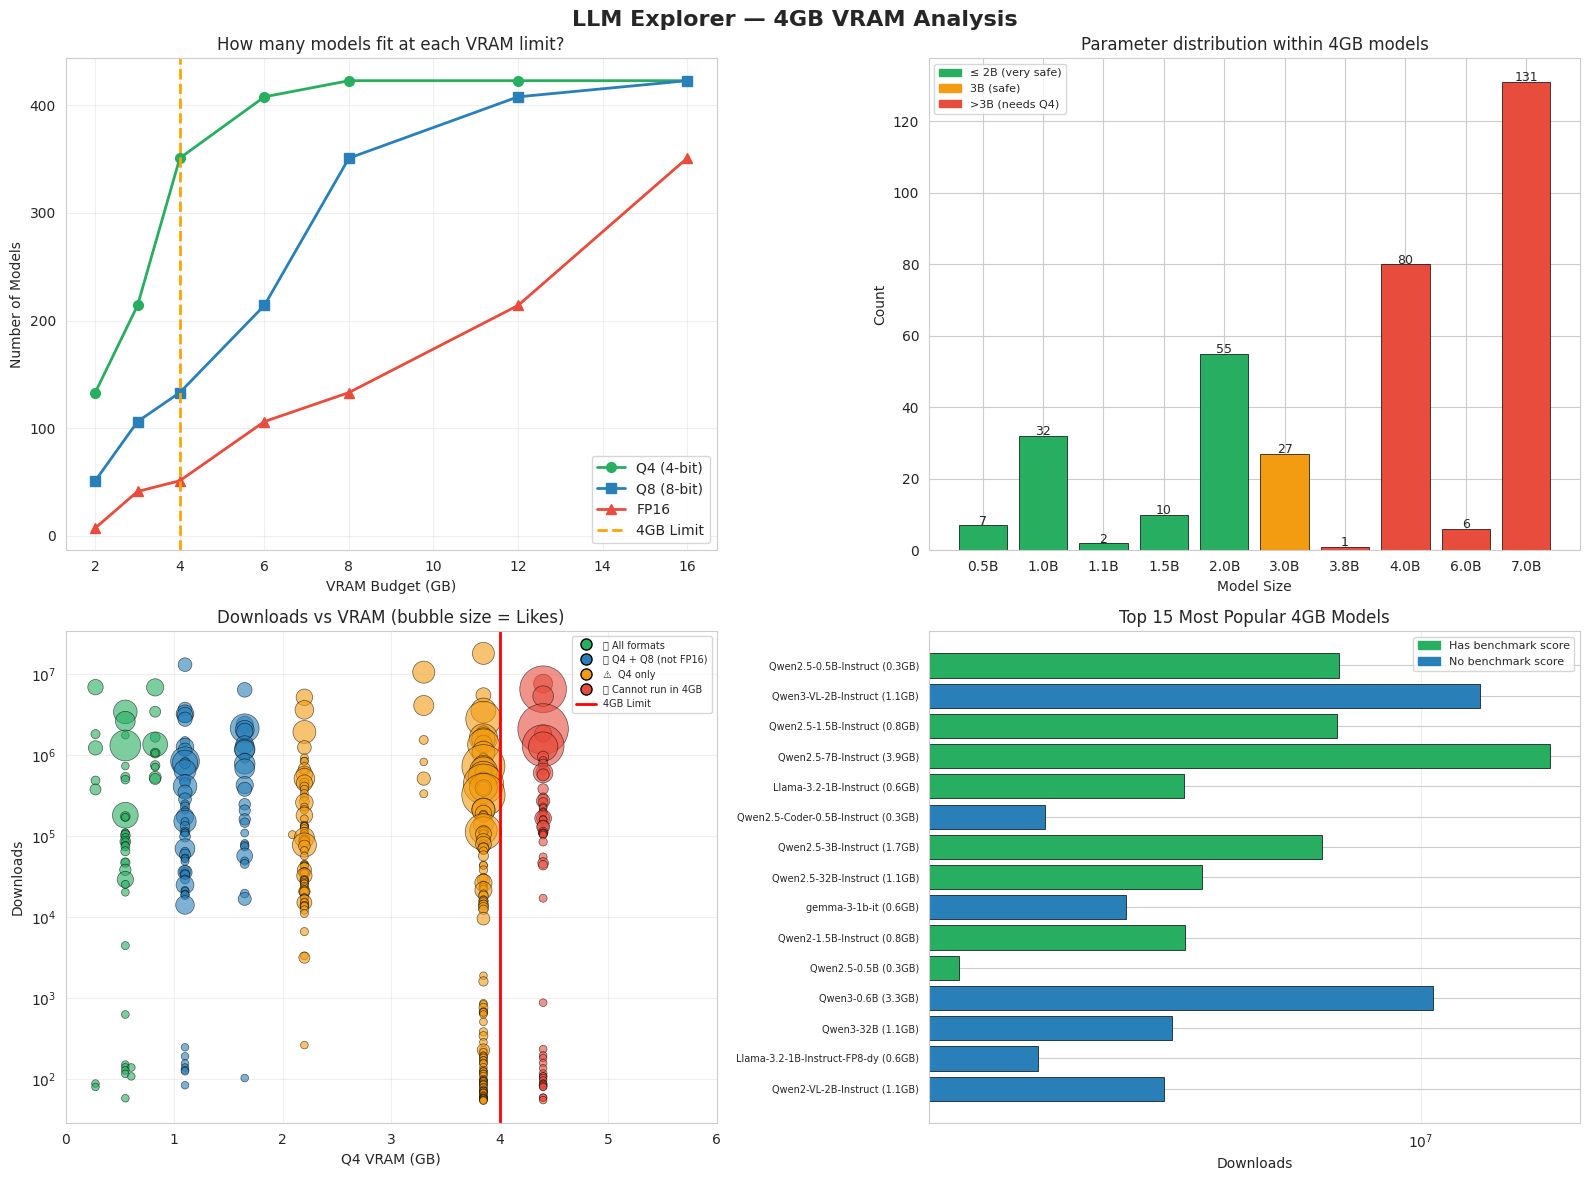

✅ Charts complete


In [6]:
# @title 📈 Visualizations — 4GB VRAM Analysis { display-mode: "form" }

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('LLM Explorer — 4GB VRAM Analysis', fontsize=16, fontweight='bold')

# Chart 1: Models available at each VRAM limit
ax1 = axes[0, 0]
vram_limits  = [2, 3, 4, 6, 8, 12, 16]
counts_q4    = [(df['VRAM_Q4_GB']   <= v).sum() for v in vram_limits]
counts_q8    = [(df['VRAM_Q8_GB']   <= v).sum() for v in vram_limits]
counts_fp16  = [(df['VRAM_FP16_GB'] <= v).sum() for v in vram_limits]
ax1.plot(vram_limits, counts_q4,   'o-', color='#27ae60', lw=2, ms=7, label='Q4 (4-bit)')
ax1.plot(vram_limits, counts_q8,   's-', color='#2980b9', lw=2, ms=7, label='Q8 (8-bit)')
ax1.plot(vram_limits, counts_fp16, '^-', color='#e74c3c', lw=2, ms=7, label='FP16')
ax1.axvline(x=4, color='orange', ls='--', lw=2, label='4GB Limit')
ax1.set_xlabel('VRAM Budget (GB)'); ax1.set_ylabel('Number of Models')
ax1.set_title('How many models fit at each VRAM limit?')
ax1.legend(); ax1.grid(alpha=0.3)

# Chart 2: Parameter distribution within 4GB
ax2 = axes[0, 1]
param_counts = df_4gb['Params_B'].value_counts().sort_index()
colors = ['#27ae60' if p <= 2 else '#f39c12' if p <= 3 else '#e74c3c' for p in param_counts.index]
bars = ax2.bar([f'{p}B' for p in param_counts.index], param_counts.values, color=colors, edgecolor='black', lw=0.5)
for bar, val in zip(bars, param_counts.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, str(val), ha='center', fontsize=9)
ax2.set_xlabel('Model Size'); ax2.set_ylabel('Count')
ax2.set_title('Parameter distribution within 4GB models')
ax2.legend(handles=[
    mpatches.Patch(color='#27ae60', label='≤ 2B (very safe)'),
    mpatches.Patch(color='#f39c12', label='3B (safe)'),
    mpatches.Patch(color='#e74c3c', label='>3B (needs Q4)'),
], fontsize=8)

# Chart 3: Downloads vs VRAM scatter (full df, fixed x-axis)
ax3 = axes[1, 0]
feasibility_colors = {
    '✅ All formats':         '#27ae60',
    '✅ Q4 + Q8 (not FP16)': '#2980b9',
    '⚠️  Q4 only':            '#f39c12',
    '❌ Cannot run in 4GB':   '#e74c3c',
}
for label, color in feasibility_colors.items():
    subset = df[df['4GB_Feasibility'] == label]
    if len(subset):
        ax3.scatter(subset['VRAM_Q4_GB'], subset['Downloads'],
                    s=subset['Likes']/5+30, c=color, alpha=0.6,
                    edgecolors='black', lw=0.5)
ax3.axvline(x=4, color='red', lw=2)
ax3.set_xlim(0, 6)
ax3.set_xlabel('Q4 VRAM (GB)'); ax3.set_ylabel('Downloads')
ax3.set_title('Downloads vs VRAM (bubble size = Likes)')
ax3.set_yscale('log'); ax3.grid(alpha=0.3)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
           markeredgecolor='black', markersize=8, label=label)
    for label, color in feasibility_colors.items()
]
legend_elements.append(Line2D([0], [0], color='red', lw=2, label='4GB Limit'))
ax3.legend(handles=legend_elements, fontsize=7)

# Chart 4: Top 15 most popular 4GB models, colored by benchmark availability
ax4 = axes[1, 1]
top15       = df_4gb.head(15).copy()
short_names = [n.split('/')[-1][:28] for n in top15['Model Name']]
# Green if has benchmark score, blue if not
bar_colors  = ['#27ae60' if b > 0 else '#2980b9' for b in top15['Benchmark_Avg']]
ax4.barh(range(len(top15)), top15['Downloads'].values, color=bar_colors, edgecolor='black', lw=0.5)
ax4.set_yticks(range(len(top15)))
ax4.set_yticklabels([f'{n} ({v:.1f}GB)' for n,v in zip(short_names, top15['VRAM_Q4_GB'])], fontsize=7)
ax4.set_xlabel('Downloads'); ax4.set_title('Top 15 Most Popular 4GB Models')
ax4.invert_yaxis(); ax4.set_xscale('log'); ax4.grid(alpha=0.3, axis='x')
ax4.legend(handles=[
    mpatches.Patch(color='#27ae60', label='Has benchmark score'),
    mpatches.Patch(color='#2980b9', label='No benchmark score'),
], fontsize=8)

plt.tight_layout()
plt.show()
print('✅ Charts complete')

In [7]:
# @title 🧭 Model Picker — Find the Right Model for YOU { display-mode: "form" }

q_vram = widgets.ToggleButtons(
    options=['< 2 GB', '2–4 GB', '4–8 GB', '8 GB+'],
    description='🖥️ My VRAM budget:',
    style={'description_width': '150px', 'button_width': '90px'}
)
q_use = widgets.ToggleButtons(
    options=['General Chat', 'Code Generation', 'Research / Analysis', 'Writing / Creative', 'Math & Reasoning'],
    description='🎯 Primary use:',
    style={'description_width': '150px', 'button_width': '130px'}
)
q_priority = widgets.ToggleButtons(
    options=['Best Quality', 'Fastest Speed', 'Balanced'],
    description='⚡ Priority:',
    style={'description_width': '150px', 'button_width': '110px'}
)
q_instruct = widgets.ToggleButtons(
    options=['Yes — I want to chat with it', 'No — I will fine-tune it', 'Not sure'],
    description='💬 Chat / Instruct:',
    style={'description_width': '150px', 'button_width': '160px'}
)
q_commercial = widgets.ToggleButtons(
    options=['Yes', 'No'],
    description='💼 Commercial use:',
    style={'description_width': '150px', 'button_width': '80px'}
)

btn    = widgets.Button(description='🔍 Find My Model!', button_style='success',
                        layout=widgets.Layout(width='200px', height='40px', margin='15px 0'))
result = widgets.Output()

def recommend(_):
    result.clear_output(wait=True)
    with result:
        vram_map = {
            '< 2 GB':  (2.0,  'Q4',  'VRAM_Q4_GB'),
            '2–4 GB':  (4.0,  'Q4',  'VRAM_Q4_GB'),
            '4–8 GB':  (8.0,  'Q8',  'VRAM_Q8_GB'),
            '8 GB+':   (16.0, 'FP16','VRAM_FP16_GB'),
        }
        vram_limit, rec_quant, quant_col = vram_map[q_vram.value]

        # Speed priority → smaller models only
        if q_priority.value == 'Fastest Speed':
            vram_limit = vram_limit * 0.6
            param_min  = 0
        elif q_priority.value == 'Best Quality':
            param_min  = 2.0
        else:
            param_min  = 0.5

        filtered = df[df[quant_col] <= vram_limit].copy()
        filtered = filtered[filtered['Params_B'] >= param_min]

        # Commercial filter
        if q_commercial.value == 'Yes':
            commercial_filter = filtered[filtered['Commercial_OK'] == True]
            if len(commercial_filter) >= 3:
                filtered = commercial_filter

        # Use-case filters
        if q_use.value == 'Code Generation':
            code_filter = filtered[filtered['Is_Code']]
            filtered = code_filter if len(code_filter) >= 3 else filtered[
                filtered['Model Name'].str.lower().str.contains('code|coder|deepseek', na=False)]
        elif q_use.value == 'Math & Reasoning':
            math_filter = filtered[
                filtered['Model Name'].str.lower().str.contains('math|reasoning|deepseek-r|qwen-math', na=False)]
            if len(math_filter) >= 3:
                filtered = math_filter

        # Prefer instruct/chat version
        if q_instruct.value == 'Yes — I want to chat with it':
            chat_filter = filtered[filtered['Is_Chat']]
            if len(chat_filter) >= 3:
                filtered = chat_filter

        top = filtered.sort_values('Efficiency', ascending=False).head(5)

        print('\n' + '='*65)
        print(f'  🎯 Recommendations:')
        print(f'     Budget: {vram_limit:.1f} GB  |  Format: {rec_quant}  |  Use: {q_use.value}')
        print('='*65)

        if len(top) == 0:
            print('\n❌ No models found. Try: more VRAM / Balanced priority / broader use case')
        else:
            for i, (_, row) in enumerate(top.iterrows(), 1):
                tags = []
                if row['Is_Chat']: tags.append('💬 Chat')
                if row['Is_Code']: tags.append('💻 Code')
                if row['Is_Math']: tags.append('🔢 Math')
                tag_str  = '  '.join(tags) if tags else '📝 Base'
                vram_val = row[quant_col]
                bench    = f'{row["Benchmark_Avg"]:.1f}' if row['Benchmark_Avg'] > 0 else '—'
                commercial = '✅ Commercial OK' if row['Commercial_OK'] else '❌ Non-commercial'
                print(f'\n  #{i}  {row["Model Name"]}')
                print(f'       {row["Params_B"]}B  |  {rec_quant}: {vram_val:.2f} GB  |  DL: {int(row["Downloads"]):,}')
                print(f'       Benchmark: {bench}  |  {commercial}')
                print(f'       {tag_str}  |  {row["4GB_Feasibility"]}')
                print(f'       🔗 https://huggingface.co/{row["Model Name"]}')

        print('\n' + '-'*65)
        tips = {
            'Q4':  '   Limited VRAM → use Q4 (GGUF). Tool: Ollama or llama.cpp. ~5–10% quality loss.',
            'Q8':  '   Decent VRAM → Q8 is nearly lossless. Tool: Ollama or Transformers.',
            'FP16':'   Plenty of VRAM → FP16 = maximum quality. Tool: Transformers or vLLM.',
        }
        print('💡 ' + tips[rec_quant])
        print('='*65)

btn.on_click(recommend)
display(widgets.VBox([q_vram, q_use, q_priority, q_instruct, q_commercial, btn, result]))

In [8]:
# @title 🗺️ Decision Framework Chart { display-mode: "form" }

from IPython.display import display, HTML


html = """
<style>
  .fw { font-family: sans-serif; max-width: 960px; margin: 0 auto; padding: 20px; }
  .fw h2 { text-align: center; font-size: 20px; margin-bottom: 24px; }
  .row { display: flex; justify-content: space-around; margin-bottom: 0px; }
  .col { display: flex; flex-direction: column; align-items: center; width: 22%; }
  .box {
    border-radius: 10px; padding: 10px 12px; text-align: center;
    font-size: 13px; width: 100%; box-sizing: border-box;
    border: 1.5px solid rgba(0,0,0,0.15);
  }
  .arrow { font-size: 22px; color: #888; margin: 4px 0; line-height: 1; }
  .section-label {
    text-align: center; font-weight: bold; font-size: 14px;
    color: #2c3e50; margin: 16px 0 12px; width: 100%;
  }
  .note {
    margin: 24px auto 8px; max-width: 700px; text-align: center;
    padding: 12px 20px; border-radius: 8px; font-size: 13px;
  }
  .note-yellow { background: #fff3cd; border: 1.5px solid #ffc107; }
  .note-red    { background: #f8d7da; border: 1.5px solid #f5c6cb; color: #666; font-size: 12px; }

  .t1 { background: #d5f5e3; border-color: #27ae60; }
  .t2 { background: #d6eaf8; border-color: #2980b9; }
  .t3 { background: #e8daef; border-color: #8e44ad; }
  .t4 { background: #fadbd8; border-color: #c0392b; }
  .u1 { background: #d1f2eb; border-color: #16a085; }
  .u2 { background: #fdebd0; border-color: #e67e22; }
  .u3 { background: #eaf4fb; border-color: #2980b9; }
  .u4 { background: #e8daef; border-color: #8e44ad; }
  .r  { background: #d1f2eb; border-color: #1abc9c; }
</style>

<div class="fw">
  <h2>🧭 How to Pick a 4GB LLM — Decision Framework</h2>

  <!-- STEP 1 -->
  <div class="section-label">STEP 1 — What is your VRAM budget?</div>
  <div class="row">
    <div class="col">
      <div class="box t1">< 2 GB<br><small>(e.g. integrated GPU)</small></div>
      <div class="arrow">↓</div>
      <div class="box t1">TinyLlama 1.1B<br>Q4 ≈ 0.6 GB</div>
    </div>
    <div class="col">
      <div class="box t2">2–4 GB<br><small>(entry GPU / M1 Mac)</small></div>
      <div class="arrow">↓</div>
      <div class="box t2">Phi-2 / Gemma-2B<br>Q4 ≈ 1–2 GB</div>
    </div>
    <div class="col">
      <div class="box t3">4–8 GB<br><small>(mid-range GPU)</small></div>
      <div class="arrow">↓</div>
      <div class="box t3">Mistral 7B<br>Q4 ≈ 4 GB</div>
    </div>
    <div class="col">
      <div class="box t4">8 GB+<br><small>(good GPU / M2+ Mac)</small></div>
      <div class="arrow">↓</div>
      <div class="box t4">Llama 3 8B<br>FP16 ≈ 16 GB</div>
    </div>
  </div>

  <!-- STEP 2 -->
  <div class="section-label">STEP 2 — What will you use it for?</div>
  <div class="row">
    <div class="col">
      <div class="box u1">📝 General Chat<br><small>Phi-2 Instruct</small></div>
    </div>
    <div class="col">
      <div class="box u2">💻 Code Gen<br><small>DeepSeek-Coder 1.3B</small></div>
    </div>
    <div class="col">
      <div class="box u3">🔢 Math & Reasoning<br><small>DeepSeek-Math 1.3B</small></div>
    </div>
    <div class="col">
      <div class="box u4">📊 Best Quality<br><small>Mistral 7B Instruct</small></div>
    </div>
  </div>

  <!-- arrows down to step 3 -->
  <div class="row" style="margin:0">
    <div class="col"><div class="arrow">↓</div></div>
    <div class="col"><div class="arrow">↓</div></div>
    <div class="col"><div class="arrow">↓</div></div>
    <div class="col"><div class="arrow">↓</div></div>
  </div>

  <!-- STEP 3 -->
  <div class="section-label">STEP 3 — How to run it?</div>
  <div class="row">
    <div class="col">
      <div class="box r">🦙 Ollama<br><small>Format: GGUF Q4<br>Simplest setup</small></div>
    </div>
    <div class="col">
      <div class="box r">⚙️ llama.cpp<br><small>Format: GGUF Q4/Q8<br>Full control</small></div>
    </div>
    <div class="col">
      <div class="box r">🤗 Transformers<br><small>Format: FP16 / Q8<br>Best quality</small></div>
    </div>
    <div class="col">
      <div class="box r">🚀 vLLM<br><small>Format: FP16<br>High throughput</small></div>
    </div>
  </div>

  <!-- notes -->
  <div class="note note-yellow">
    💡 <strong>Smart Rule:</strong> Even if you have 16 GB, use at most half for your model.<br>
    Leave room for your OS, browser, and other apps. Running cool = running fast.
  </div>
  <div class="note note-red">
    ⚠️ All VRAM estimates include ~10% overhead for KV cache + runtime. Always leave headroom.
  </div>
</div>
"""

display(HTML(html))

---
## ✅ Data Sources & Methodology

| Field | Source |
|-------|--------|
| Model names & stats | HuggingFace API (`list_models`) |
| Parameter counts | Read from model card YAML, or parsed from model name |
| VRAM estimates | `Parameters × bytes_per_param × 1.10 overhead` |
| Downloads & Likes | Real HuggingFace community stats |
| Benchmark scores | Open LLM Leaderboard (`open-llm-leaderboard/contents`) |
| Efficiency score | `(Downloads + Likes×10) / (VRAM_Q4 + 0.1) × (1 + Recency/3650) × (1 + Benchmark/100)` — for ranking only |

> ⚠️ **Parameter counts & VRAM estimates are approximate.** Always verify before deploying.

---

## 🏆 How Benchmark Scores Are Calculated

Benchmark scores come from the [Open LLM Leaderboard](https://huggingface.co/spaces/open-llm-leaderboard/open_llm_leaderboard). Each model is evaluated on six standardized tests:

| Test | What It Measures |
|------|-----------------|
| IFEval | Can the model follow instructions accurately? |
| BBH (Big Bench Hard) | Complex multi-step reasoning |
| MATH Lvl 5 | High school competition math problems |
| GPQA | Graduate-level science questions |
| MUSR | Multi-step reasoning with long context |
| MMLU-PRO | Knowledge across 57 academic subjects |

`Average ⬆️` is the mean of these six scores. Range is roughly **0–50** for small models (not 0–100).

| Score Range | Typical Model Size |
|-------------|-------------------|
| 0–15 | Very small (0.5B–1B) |
| 15–25 | Small (1.5B–3B) |
| 25–40 | Medium (7B–9B) |
| 40+ | Large (34B+) |

> ⚠️ Only ~19% of our models have benchmark scores — many models are not submitted to the leaderboard.

---

## 🆚 How We Compare to LLM Explorer

[LLM Explorer](https://llm-explorer.com/list/?4GB) is a curated directory of LLM models. Here is how our notebook compares:

| | LLM Explorer | This Notebook |
|--|--|--|
| Data source | Manually curated + reviewed | HuggingFace API (live) |
| Model coverage | 50,000+ models | ~300 models (keyword search) |
| VRAM judgment | Human-verified | Formula: `params × bytes × 1.10` |
| Ranking formula | Popularity 40% + Recency 25% + Expert 35% | Downloads + Likes + Recency + Benchmark |
| Benchmark data | MMLU / ARC / GSM8K and more | Open LLM Leaderboard (6 tests) |
| Filters | VRAM / format / license / context / MoE | VRAM / format / commercial use |
| Updates | Periodic manual updates | Every time you run the notebook |

**Key takeaway:** LLM Explorer is more comprehensive and human-verified. Our notebook is more transparent — you can see exactly how every number is calculated, and the data is always fresh.

---

## 🛠️ Useful Tools to Run Models Locally

| Tool | Best For | Interface |
|------|----------|-----------|
| [LM Studio](https://lmstudio.ai) | Beginners — easiest setup | GUI |
| [Ollama](https://ollama.com) | Simple CLI, great defaults | CLI |
| [llama.cpp](https://github.com/ggerganov/llama.cpp) | Full control, lightweight | CLI |
| [HuggingFace Transformers](https://huggingface.co/docs/transformers) | Research & fine-tuning | Python |
| [vLLM](https://github.com/vllm-project/vllm) | High-throughput serving | Python |
| [LLM Explorer](https://llm-explorer.com/list/?4GB) | Browse 4GB-compatible models | Web |

> 📌 **Note:** LLM Explorer may occasionally be unavailable. You can always filter models directly on [HuggingFace](https://huggingface.co/models).